In [18]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv' , 'order_items') # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Suleman@0303',
    database='ecommerce1'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'E:/Data_Analytics/Ecommerce_dataSet'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Suleman@0303',
    database='ecommerce1'
)

cur = db.cursor()

# 1. List all unique cities where customers are located.

In [6]:
query = """select distinct customer_city from customers"""

cur.execute(query)

data = cur.fetchall()

data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# 2. Count the number of orders placed in 2017.

In [15]:
query = """select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query)

data = cur.fetchall()

"total order placed in 2017 are ",data [0] [0]

('total order placed in 2017 are ', 45101)

# 3. Find the total sales per category.

In [60]:
query = """select products.product_category category, round(sum(payments.payment_value),2) sales
           from products join order_items 
           on products.product_id = order_items.product_id
           join payments
           on payments.order_id = order_items.order_id
           group by category"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales"])
df['Category'] = df['Category'].str.title()
df

,Category,Sales
0,Perfumery,506738.66
1,Furniture Decoration,1430176.39
2,Telephony,486882.05
3,Bed Table Bath,1712553.67
4,Automotive,852294.33
...,...,...
69,Cds Music Dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children'S Clothing,785.67
72,Pc Gamer,2174.43


# 4. Calculate the percentage of orders that were paid in installments.

In [28]:
query = """select (sum(case when payment_installments >= 1 then 1 else 0 end))/count(*)*100 from payments"""

cur.execute(query)

data = cur.fetchall()

data


[(Decimal('99.9981'),)]

# 5. Count the number of customers from each state. 

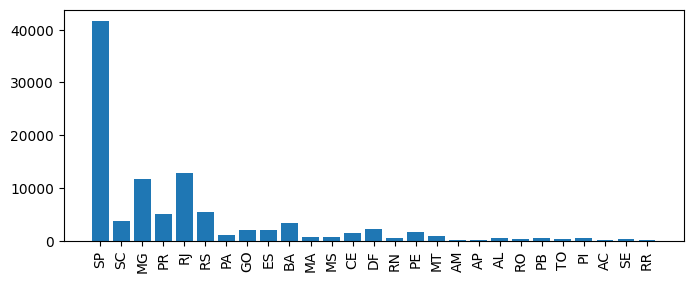

In [63]:
query = """select customer_state, count(customer_id) from customers group by customer_state"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["State", "Customer_count"])
plt.figure(figsize = (8,3))
plt.bar(df["State"],df["Customer_count"])
plt.xticks(rotation = 90)
plt.show()

# 6. Calculate the number of orders per month in 2018.

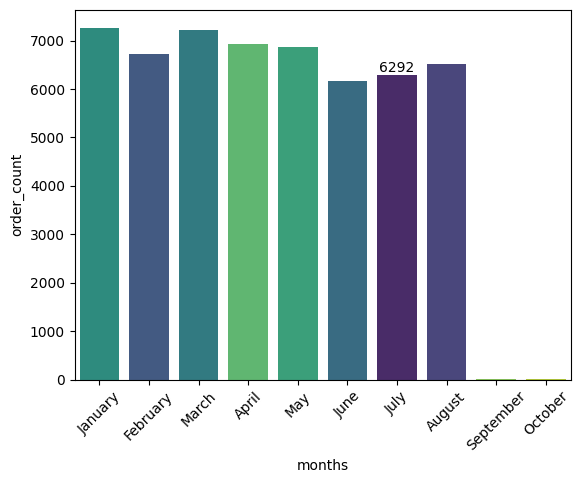

In [83]:
query = """select monthname(order_purchase_timestamp) months, count(order_id) from orders order_count
           where year(order_purchase_timestamp) = 2018 group by months"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
df
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]
ax = sns.barplot(x = df["months"], y = df["order_count"], data = df, order = o, hue = "months", palette = "viridis")
ax.bar_label(ax.containers[0])
plt.xticks(rotation = 45)
plt.show()

# 7. Find the average number of products per order, grouped by customer city.

In [22]:
query = """with count_per_order as
          (select orders.order_id, orders.customer_id , count(order_items.order_id) as oc
           from orders join order_items
           on orders.order_id = order_items.order_id
           group by orders.order_id, orders.customer_id)

           select customers.customer_city, round(avg(count_per_order.oc),2)
           from customers join count_per_order 
           on customers.customer_id = count_per_order.customer_id
           group by customers.customer_city"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Customer_City", "Avg_Prod/Order"])
df['Customer_City'] = df['Customer_City'].str.title()
df

,Customer_City,Avg_Prod/Order
0,Sao Paulo,1.16
1,Sao Jose Dos Campos,1.14
2,Porto Alegre,1.17
3,Indaial,1.12
4,Treze Tilias,1.27
...,...,...
4105,Japaratuba,1.00
4106,Sebastiao Leal,1.00
4107,Buriti,3.00
4108,Morro Agudo De Goias,1.00


# 8. Calculate the percentage of total revenue contributed by each product category.

In [26]:
query = """select products.product_category Category, 
           round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
           from products join order_items 
           on products.product_id = order_items.product_id
           join payments
           on payments.order_id = order_items.order_id
           group by category"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales_Percentage"])
df['Category'] = df['Category'].str.title()
df

,Category,Sales_Percentage
0,Perfumery,3.17
1,Furniture Decoration,8.93
2,Telephony,3.04
3,Bed Table Bath,10.70
4,Automotive,5.32
...,...,...
69,Cds Music Dvds,0.01
70,La Cuisine,0.02
71,Fashion Children'S Clothing,0.00
72,Pc Gamer,0.01


# 9. Identify the correlation between product price and the number of times a product has been purchased.

In [29]:
import numpy as np
query = """select products.product_category, count(order_items.product_id),
           round(avg (order_items.price),2) 
           from products join order_items
           on products.product_id = order_items.product_id
           group by products.product_category"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category","Order_Count","Price"])
arr1 = df["Order_Count"]
arr2 = df["Price"]
np.corrcoef([arr1,arr2])

array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

# 10. Calculate the total revenue generated by each seller, and rank them by revenue.

In [32]:
query = """select *, dense_rank() over(order by revenue desc) as rn 
           from
          (select order_items.seller_id, sum(payments.payment_value) revenue
           from order_items join payments
           on order_items.order_id = payments.order_id
           group by order_items.seller_id) as a"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Seller_ID", "Revenue","Ranking"])
df

,Seller_ID,Revenue,Ranking
0,7c67e1448b00f6e969d365cea6b010ab,507166.907302,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.039840,2
2,4a3ca9315b744ce9f8e9374361493884,301245.269765,3
3,1f50f920176fa81dab994f9023523100,290253.420128,4
4,53243585a1d6dc2643021fd1853d8905,284903.080498,5
...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,19.209999,3082
3091,702835e4b785b67a084280efca355756,18.559999,3083
3092,4965a7002cca77301c82d3f91b82e1a9,16.360001,3084
3093,77128dec4bec4878c37ab7d6169d6f26,15.220000,3085


# 11. Calculate the moving average of order values for each customer over their order history.

In [35]:
query = """select customer_id, order_purchase_timestamp,
           avg(payment) over (partition by customer_id order by order_purchase_timestamp 
           rows between 2 preceding and current row) as mov_avg
           from
          (select orders.customer_id,  orders.order_purchase_timestamp, payments.payment_value as payment
           from payments join orders
           on orders.order_id = payments.order_id) as a"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.010002
...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000


# 12. Calculate the cumulative sales per month for each year.

In [65]:
query = """select years, months, payments, sum(payments) over (order by years, months) as cumulative_sales 
           from
          (select year(orders.order_purchase_timestamp) as years, month(orders.order_purchase_timestamp) as months, 
           round(sum(payments.payment_value),2) as payments 
           from orders join payments
           on orders.order_id = payments.order_id
           group by years, months order by years, months) as a"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Years","Months","Sales","Cumulative_Sales"])
df


,Years,Months,Sales,Cumulative_Sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# 13.  Calculate the year-over-year growth rate of total sales.

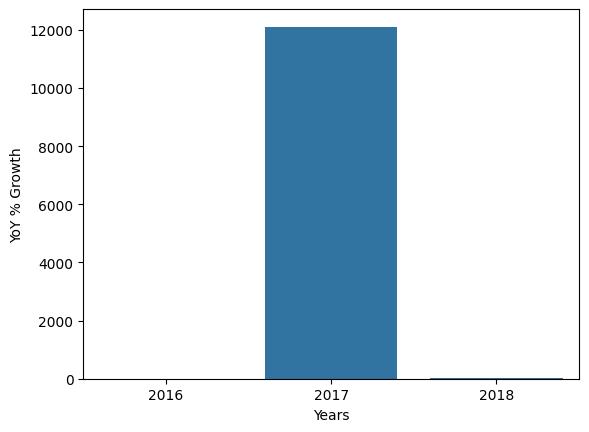

In [68]:
query = """select years, round(((payment - lag(payment,1) over (order by years))/
           lag(payment,1) over (order by years))*100,3) as previous_sales 
           from
          (select year(orders.order_purchase_timestamp) as years, round(sum(payments.payment_value),2) as payment 
           from orders join payments
           on orders.order_id = payments.order_id
           group by years order by years) as a"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Years","YoY % Growth"])
sns.barplot(x = "Years", y = "YoY % Growth", data = df)
plt.show()

# 14. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [45]:
# This showing no result because there is no customer in our dataset who made a purchase within next 6 months after 1st purchase.
# 100 * (count(distinct a.customer_id)/count(distinct b.custoemr_id)) 

query = """with a as 
          (select customers.customer_id, min(orders.order_purchase_timestamp) as first_order
           from orders join customers
           on customers.customer_id = orders.customer_id
           group by customers.customer_id)

           select a.customer_id , count(distinct orders.order_purchase_timestamp)
           from a join orders
           on a.customer_id = orders.customer_id
           and orders.order_purchase_timestamp > first_order
           and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
           group by a.customer_id """

cur.execute(query)

data = cur.fetchall()
data 

[]

# 15. Identify the top 3 customers who spent the most money in each year.

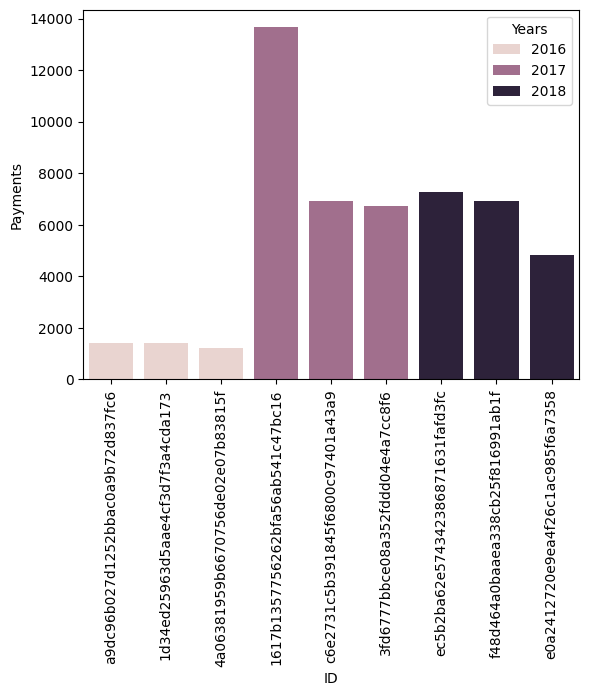

In [52]:
query = """select years, customer_id, payment, d_rank
           from
          (select year(orders.order_purchase_timestamp) years, orders.customer_id, sum(payments.payment_value) payment,
           dense_rank() over(partition by year(orders.order_purchase_timestamp)
           order by sum(payments.payment_value) desc) d_rank
           from orders join payments 
           on orders.order_id = payments.order_id
           group by years, orders.customer_id) as a
           where d_rank<=3 
        """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Years","ID","Payments","Ranking"])
sns.barplot(x = "ID", y = "Payments", data = df, hue = "Years")
plt.xticks(rotation = 90)
plt.show()